## Grupo 1 | MCDI500 - Programación para la ciencia de datos

### Integrantes

- Pablo Ignacio Balbontin Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Munoz Carnot @dark452
- Mario Alejandro Lopez Pulgar @malp2203

### Descripción del proyecto - Fase 2
El objetivo del proyecto es realizar un análisis del impacto la utilización y frecuencia de uso de la IA generativa sobre el rendimiento académico y el nivel de agotamiento de
estudiantes universitarios. En esta fase nos concentraremos en explorar el dataset en profundidad, limpiar y transformar los datos para dejarlos listos para la etapa de modelado.

### Objetivo General
Construir una pipeline de datos reproducible que realice las siguientes operaciones sobre el dataset:

- Limpieza
- Codificado
- Escalado
- Preparado para modelado posterior

### Objetivos Específicos

- Obtener y explorar los datos verificando su estructura y calidad.
- Limpiar gestionando rigurosamente los valores nulos.
- Transformar las variables categóricas ordinales con codificación por mapeo.
- Transformar las variables categóricas nominales con One-Hot Encoding.
- Estandarizar y normalizar las variables continuas según su distribución.
- Validar técnicamente el resultado antes de exportar.

**Atributos:** `Student_ID`, `Major_Category`, `Year_of_Study`, `Pre_Semester_GPA`, `Weekly_GenAI_Hours`, `Primary_Use_Case`,
`Prompt_Engineering_Skill`, `Tool_Diversity`, `Paid_Subscription`, `Traditional_Study_Hours`, `Perceived_AI_Dependency`, `Institutional_Policy`, `Anxiety_Level_During_Exams`, `Skill_Retention_Score`, además las variables
objetivo `Burnout_Risk_Level`(High, Low y Medium) y `Post_Semester_GPA`.

## 1. Importación de librerías

Se importan las librerías necesarias para cargar, explorar, transformar y visualizar el dataset.

| Librería | Función |
|---|---|
| `pandas` | Cargar y manipular la tabla de datos (el `DataFrame`). |
| `numpy` | Operaciones numéricas y fijación de semilla aleatoria. |
| `matplotlib` / `seaborn` | Visualizaciones del EDA (histogramas, boxplots, heatmap). |
| `sklearn.preprocessing` | Las herramientas de codificación (`LabelEncoder`, `OneHotEncoder`) y escalamiento (`StandardScaler`). |

`np.random.seed(42)` fija la semilla aleatoria: garantiza que cualquier proceso con azar dé **siempre el mismo resultado**, asegurando la *reproducibilidad* exigida en la fase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## 2. Carga del dataset
### Función Carga de dataset
Carga el dataset raw desde la ruta relativa indicada utilizando `pd.read_csv`. Si la ruta no existe lanza `FileNotFoundError` con mensaje descriptivo.

In [2]:
def load_data(file_path: str) -> pd.DataFrame:
    """Carga dataset raw, desde un archivo CSV

    Parámetros
    ----------
    file_path : str
        Ruta del archivo CSV utilizado como entrada.

    Retorno
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Excepción
    ---------
    FileNotFoundError
        Si la ruta al archivo CSV no existe. Se muestra un mensaje de error
    """
    try:
        df = pd.read_csv(file_path)
    except FileNotfoundError:
        raise FileNotFoundError(
            f"No se encontró el archivo '{file_path}'."
            "Verificar que el archivo CSV se encuentre en data/raw."
        )
    df = pd.read_csv(file_path)
    return df

In [3]:
df = load_data('../data/raw/ai_student_impact_dataset.csv')
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 50,000 filas x 16 columnas


## 3. Análisis Exploratorio de Datos (EDA)

Antes de transformar cualquier variable se realiza una inspección completa del dataset. El objetivo es entender la estructura, detectar problemas de calidad y fundamentar las decisiones de limpieza y transformación.

### 3.1 Dimensiones y tipos de datos

La función `show_tipos` muestra:

1. **Dimensiones** (`shape`): Cantidad de columnas y filas
2. **Tipos de datos** (`dtypes`): Qué columnas son numéricas y cuáles son texto. Las de texto `object` son las que se codificarán más adelante.


In [4]:
def show_tipos(df: pd.DataFrame) -> None:
    """Muestra dimensiones y tipos de datos del dataset."""
    print(f'Dimensiones: {df.shape}')
    print()
    print(f"{'Columna':<27} {'Tipo Dato'}")
    print("-" * 37)
    print(df.dtypes)
    print()

show_tipos(df)


Dimensiones: (50000, 16)

Columna                     Tipo Dato
-------------------------------------
Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object



### 3.2 Valores nulos

La función `show_nulos` muestra cuántos datos faltan en cada columna y su porcentaje. Se espera confirmar que el dataset no contiene valores nulos, según lo declarado en la Fase 1.

**Estrategia de imputación (si se detectaran nulos):**
- Variables numéricas continuas: imputación por mediana.
- Variables categóricas: imputación por moda o creación de categoría `Desconocido`.

In [5]:
def show_nulos(df: pd.DataFrame) -> None:
    """Muestra valores nulos por columna."""
    print('Valores nulos por columna:')
    print("-" * 31)
    print(df.isnull().sum())
    print()

show_nulos(df)

Valores nulos por columna:
-------------------------------
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64



### 3.3 Estadísticas descriptivas

Estadísticas descriptivas (`describe()`): Media, mínimo, máximo, etc., de las variables numéricas, útil para detectar rangos raros o valores atípicos.

La función `show_estadisticas` muestra un resumen de las columnas numéricas:
- `count`: cantidad de valores no nulos
- `mean`: promedio
- `std`: desviación estándar
- `min` / `max`: valores extremos
- `25%`, `50%`, `75%`: cuartiles

In [6]:
def show_estadisticas(df: pd.DataFrame) -> None:
    """Muestra estadísticas descriptivas."""
    print('Estadísticas descriptivas:')
    print("-" * 31)
    print(df.describe())

show_estadisticas(df)

Estadísticas descriptivas:
-------------------------------
          Student_ID  Pre_Semester_GPA  Weekly_GenAI_Hours  Tool_Diversity  \
count   50000.000000      50000.000000        50000.000000     50000.00000   
mean   125000.500000          3.146102            8.427752         2.80026   
std     14433.901067          0.478854            8.269490         1.18802   
min    100001.000000          1.183000            0.000000         1.00000   
25%    112500.750000          2.834000            2.390000         2.00000   
50%    125000.500000          3.210000            5.800000         3.00000   
75%    137500.250000          3.521000           11.720000         4.00000   
max    150000.000000          3.998000           40.000000         5.00000   

       Traditional_Study_Hours  Perceived_AI_Dependency  \
count             50000.000000             50000.000000   
mean                 11.209271                 3.505360   
std                   5.156426                 1.820812   
mi

### 3.4 Visualizaciones

#### Boxplots

Un *boxplot* (diagrama de caja) muestra la distribución de una variable numérica en cinco estadísticos: mínimo, primer cuartil (Q1), mediana (Q2), tercer cuartil (Q3) y máximo. Los puntos fuera de los bigotes (1.5 × IQR) se consideran valores atípicos.

Los revisamos **antes** de transformar los datos para detectar:
- Rangos esperados vs. reales
- Efectos techo/piso (valores que se acumulan en los extremos)
- Valores atípicos que podrían requerir tratamiento


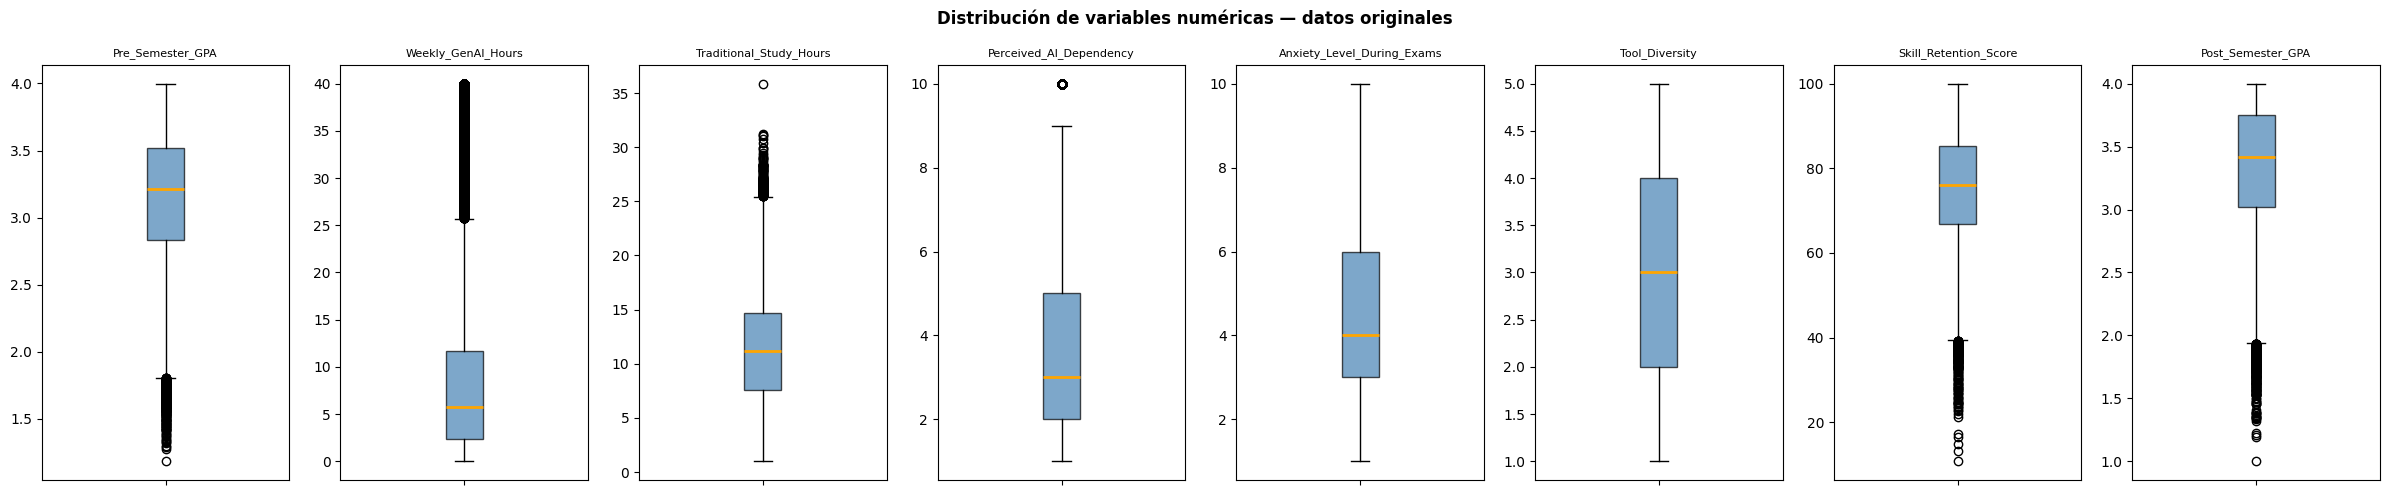

In [7]:
def mostrar_boxplots(df: pd.DataFrame, columnas: list, titulo: str) -> None:
    """Genera un boxplot por cada columna numérica indicada.

    Parámetros
    ----------
    df       : pd.DataFrame
    columnas : list[str] — columnas numéricas a graficar
    titulo   : str — título general de la figura
    """
    n = len(columnas)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, columnas):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7),
                   medianprops=dict(color='orange', linewidth=2))
        ax.set_title(col, fontsize=8, wrap=True)
        ax.tick_params(axis='x', labelbottom=False)
    fig.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


COLUMNAS_NUMERICAS_RAW = [
    'Pre_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams',
    'Tool_Diversity',
    'Skill_Retention_Score',
    'Post_Semester_GPA',
]

mostrar_boxplots(df, COLUMNAS_NUMERICAS_RAW, 'Distribución de variables numéricas — datos originales')

### 3.5 Análisis de valores atípicos (outliers)

El método **IQR (Rango Intercuartílico)** define como valor atípico cualquier punto fuera del rango:

- **Límite inferior:** Q1 − 1.5 × IQR
- **Límite superior:** Q3 + 1.5 × IQR

Se aplica sobre las 8 variables numéricas **antes de cualquier transformación** para determinar si requieren tratamiento. Este análisis responde a la tarea de limpieza indicada en la Guía de Desarrollo F2 (sección 3.5): *"Tratamiento de inconsistencias y valores atípicos si se identifican."*

In [8]:
def detectar_outliers(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    """Detecta valores atípicos por método IQR y retorna tabla resumen.

    Parámetros
    ----------
    df       : pd.DataFrame — dataset original (sin escalar)
    columnas : list[str] — columnas numéricas a analizar

    Retorna
    -------
    pd.DataFrame con Q1, Q3, IQR, límites y conteo de outliers por variable
    """
    resumen = []
    for col in columnas:
        if col not in df.columns:
            continue
        Q1    = df[col].quantile(0.25)
        Q3    = df[col].quantile(0.75)
        IQR   = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        n_out = int(((df[col] < lim_inf) | (df[col] > lim_sup)).sum())
        resumen.append({
            'Variable'     : col,
            'Q1'           : round(Q1, 2),
            'Q3'           : round(Q3, 2),
            'IQR'          : round(IQR, 2),
            'Lím. inferior': round(lim_inf, 2),
            'Lím. superior': round(lim_sup, 2),
            'N outliers'   : n_out,
            '% del total'  : round(n_out / len(df) * 100, 2),
        })

    return pd.DataFrame(resumen).set_index('Variable')

resumen_outliers = detectar_outliers(df, COLUMNAS_NUMERICAS_RAW)
print(resumen_outliers.to_string())

                               Q1     Q3    IQR  Lím. inferior  Lím. superior  N outliers  % del total
Variable                                                                                              
Pre_Semester_GPA             2.83   3.52   0.69           1.80           4.55         328         0.66
Weekly_GenAI_Hours           2.39  11.72   9.33         -11.60          25.72        2583         5.17
Traditional_Study_Hours      7.56  14.71   7.15          -3.17          25.44         161         0.32
Perceived_AI_Dependency      2.00   5.00   3.00          -2.50           9.50         190         0.38
Anxiety_Level_During_Exams   3.00   6.00   3.00          -1.50          10.50           0         0.00
Tool_Diversity               2.00   4.00   2.00          -1.00           7.00           0         0.00
Skill_Retention_Score       66.82  85.19  18.37          39.26         112.74         216         0.43
Post_Semester_GPA            3.02   3.75   0.73           1.94           

### Decisión técnica: conservar los valores atípicos

El análisis IQR identifica puntos fuera del rango [Q1 − 1.5·IQR, Q3 + 1.5·IQR] en algunas variables. Sin embargo, **no se aplica eliminación ni imputación** por las siguientes razones técnicas:

| Argumento | Detalle |
|---|---|
| **Dataset sintético** | Los datos fueron generados con rangos predefinidos. Los extremos son parte del diseño, no errores de captura. |
| **Valores dentro del dominio válido** | `Weekly_GenAI_Hours` tiene techo en 40 h/sem; `Skill_Retention_Score` va de 0 a 100; todos los puntos extremos están dentro de los límites declarados por la fuente. |
| **Son informativos** | Representan perfiles reales en los extremos: estudiantes con uso muy intensivo de IA o con retención muy baja/alta. Eliminarlos sesgaría el dataset hacia el centro. |
| **Sin valores nulos** | La guía F2 (sección 3.3) enfatiza el manejo de NA. Al no existir nulos, la limpieza se reduce a la revisión de atípicos, que resultan válidos. |

**Conclusión:** los valores identificados como estadísticamente atípicos son representativos del fenómeno estudiado. Se conservan íntegramente para no perder información en el modelado.


### 3.6 Frecuencia de categorías

La función `show_categories` muestra el conteo de cada categoría en las columnas de tipo `object`. Permite verificar que no existan valores inesperados ni categorías con frecuencia muy baja antes de aplicar One-Hot Encoding.

In [9]:
def show_categories(df: pd.DataFrame) -> None:
    """Muestra la repetición de las variables por columna.

    Parámetros
    ----------
    df       : pd.DataFrame — dataset original (sin escalar)

    Retorna
    -------
    None
    """
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    for col in cat_cols:
      print(f"\n{col}:")
      print(df[col].value_counts().to_string())

show_categories(df)


Major_Category:
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933

Year_of_Study:
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430

Primary_Use_Case:
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340

Prompt_Engineering_Skill:
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809

Institutional_Policy:
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788

Burnout_Risk_Level:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487


### 3.7 Análisis de asimetría (skewness)

El skewness mide cuánto se aleja la distribución de una forma simétrica. Este análisis fundamenta la elección entre `StandardScaler` y `MinMaxScaler`.

**Criterio aplicado:**
- |skewness| < 0.5 → distribución aproximadamente simétrica → **StandardScaler**
- 0.5 ≤ |skewness| < 1.0 → asimetría moderada → se evalúa caso a caso
- |skewness| ≥ 1.0 → asimetría pronunciada → **MinMaxScaler**

Para variables de escala Likert (1–10) o discreta acotada (1–5) se aplica **MinMaxScaler** independientemente del skewness, ya que el rango está definido por el dominio.

In [10]:
def compute_skewness(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Calcula skewness de columnas numéricas y recomienda escalador."""
    resultados = []
    likert_cols = {'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Tool_Diversity'}

    for col in cols:
        if col not in df.columns:
            print(f'[WARN] Columna {col} no encontrada.')
            continue
        skew_val = df[col].skew()
        abs_skew = abs(skew_val)

        if col in likert_cols:
            interpretacion = 'Escala discreta acotada (dominio definido)'
            escalador = 'MinMaxScaler'
        elif abs_skew < 0.5:
            interpretacion = 'Aproximadamente simétrica'
            escalador = 'StandardScaler'
        elif abs_skew < 1.0:
            interpretacion = 'Asimetría moderada'
            escalador = 'StandardScaler (revisar histograma)'
        else:
            interpretacion = 'Asimetría pronunciada'
            escalador = 'MinMaxScaler'

        resultados.append({
            'Variable':              col,
            'Skewness':              round(skew_val, 4),
            'Interpretación':        interpretacion,
            'Escalador_Recomendado': escalador
        })

    tabla = pd.DataFrame(resultados)
    print('Análisis de skewness — criterio de selección de escalador:')
    print('-' * 75)
    print(tabla.to_string(index=False))
    print()
    return tabla

NUMERIC_COLS = [
    'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
    'Traditional_Study_Hours', 'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score'
]
tabla_skewness = compute_skewness(df, NUMERIC_COLS)

Análisis de skewness — criterio de selección de escalador:
---------------------------------------------------------------------------
                  Variable  Skewness                             Interpretación               Escalador_Recomendado
          Pre_Semester_GPA   -0.6020                         Asimetría moderada StandardScaler (revisar histograma)
        Weekly_GenAI_Hours    1.6098                      Asimetría pronunciada                        MinMaxScaler
            Tool_Diversity    0.1668 Escala discreta acotada (dominio definido)                        MinMaxScaler
   Traditional_Study_Hours    0.1301                  Aproximadamente simétrica                      StandardScaler
   Perceived_AI_Dependency    0.6554 Escala discreta acotada (dominio definido)                        MinMaxScaler
Anxiety_Level_During_Exams    0.3617 Escala discreta acotada (dominio definido)                        MinMaxScaler
         Post_Semester_GPA   -0.6751                 

## 4. Limpieza básica de datos

Limpiar los datos significa dejar los datos completos y consistentes. Tomamos dos decisiones, cada
una justificada técnicamente:

**1) Eliminar `Student_ID`:** es un identificador único sin información predictiva. Mantenerlo podría introducir fuga de datos en modelos que asignen peso a identificadores correlacionados con el orden de registro.

**2) Sin imputación de nulos:** el dataset no contiene valores nulos en ninguna columna, verificado con `show_nulos` en la sección anterior.

In [11]:
def drop_id_column(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Elimina la columna identificadora sin valor predictivo.

    Parámetros
    ----------
    df       : pd.DataFrame — dataset original (sin escalar)
    col      : String con el nombre de la columna

    Retorna
    -------
    pd.DataFram: Datos cargados en un DataFrame
    """
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f'[OK] Columna {col} eliminada. Shape resultante: {df.shape}')
    else:
        print(f'[WARN] Columna {col} no encontrada.')
    return df

df = drop_id_column(df,'Student_ID')
df.head()

[OK] Columna Student_ID eliminada. Shape resultante: (50000, 15)


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 5. Conversión de variable booleana

`Paid_Subscription` es de tipo `bool`. La conversión explícita a `int64` garantiza compatibilidad con todos los estimadores de scikit-learn.

In [12]:
def cast_bool_to_int(df: pd.DataFrame, col: str = 'Paid_Subscription') -> pd.DataFrame:
    """Convierte columna booleana a entero (False->0, True->1).

    Parámetros
    ----------
    df  : pd.DataFrame
    col : nombre de la columna booleana (default 'Paid_Subscription')

    Retorna
    -------
    pd.DataFrame con la columna convertida a int64
    """
    if col not in df.columns:
        print(f'[WARN] Columna {col} no encontrada.')
        return df
    print(f'[INFO] {col} — dtype antes: {df[col].dtype}')
    # Conversión via numpy array, evita inferencia de tipos de pandas
    df[col] = df[col].to_numpy().astype(int)
    print(f'[INFO] {col} — dtype despues: {df[col].dtype}')
    if df[col].dtype != 'int64':
        raise TypeError(
            f'La conversión no produjo int64. dtype resultante: {df[col].dtype}.'
        )
    conteo = df[col].value_counts().sort_index().to_dict()
    print(f'[OK] {col} convertida a int64. Distribución: {conteo}')
    return df

df = cast_bool_to_int(df)
df.head()

[INFO] Paid_Subscription — dtype antes: bool
[INFO] Paid_Subscription — dtype despues: int64
[OK] Paid_Subscription convertida a int64. Distribución: {0: 28846, 1: 21154}


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 6. Codificación de variables ordinales

Las variables ordinales poseen una relación de orden inherente que los modelos pueden aprovechar. Se asignan enteros consecutivos según jerarquía real.

Aplicar **One-Hot Encoding** a variables ordinales destruiría la relación de orden y expandiría innecesariamente el espacio de features.

| Variable | Tipo | Mapping |
|---|---|---|
| `Year_of_Study` | Ordinal | Freshman=0, Sophomore=1, Junior=2, Senior=3, Graduate=4 |
| `Prompt_Engineering_Skill` | Ordinal | Beginner=0, Intermediate=1, Advanced=2 |
| `Burnout_Risk_Level` | Ordinal (target clasificación) | Low=0, Medium=1, High=2 |

In [13]:
def encode_ordinal(df: pd.DataFrame, col: str, order: list) -> pd.DataFrame:
    """Codifica variable ordinal asignando enteros según el orden definido.

    Parámetros
    ----------
    df    : pd.DataFrame
    col   : nombre de la columna a codificar
    order : lista de categorías en orden ascendente
            Ejemplo: ['Low', 'Medium', 'High'] -> {Low:0, Medium:1, High:2}

    Retorna
    -------
    pd.DataFrame con la columna reemplazada por valores enteros
    """
    if col not in df.columns:
        print(f'[WARN] Columna {col} no encontrada.')
        return df
    mapping = {cat: idx for idx, cat in enumerate(order)}
    df[col] = df[col].map(mapping)
    nulos_post = df[col].isnull().sum()
    if nulos_post > 0:
        print(f'[ERROR] {col}: {nulos_post} valores sin mapeo. Verificar order.')
    else:
        print(f'[OK] {col} codificada. Mapping: {mapping}')
    return df

In [14]:
# Year_of_Study: orden académico natural
df = encode_ordinal(df, 'Year_of_Study',
                    order=['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'])

# Prompt_Engineering_Skill: progresión de dominio
df = encode_ordinal(df, 'Prompt_Engineering_Skill',
                    order=['Beginner', 'Intermediate', 'Advanced'])

# Burnout_Risk_Level: target de clasificación — NO se escala
df = encode_ordinal(df, 'Burnout_Risk_Level',
                    order=['Low', 'Medium', 'High'])

print('\nDistribucion post-codificacion ordinal:')
print(df[['Year_of_Study', 'Prompt_Engineering_Skill', 'Burnout_Risk_Level']]
      .apply(lambda c: c.value_counts()).T)
df.head()

[OK] Year_of_Study codificada. Mapping: {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}
[OK] Prompt_Engineering_Skill codificada. Mapping: {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
[OK] Burnout_Risk_Level codificada. Mapping: {'Low': 0, 'Medium': 1, 'High': 2}

Distribucion post-codificacion ordinal:
                                0        1        2        3       4
Year_of_Study             11031.0   9860.0  11045.0  10634.0  7430.0
Prompt_Engineering_Skill  18495.0  17696.0  13809.0      NaN     NaN
Burnout_Risk_Level        16369.0  21144.0  12487.0      NaN     NaN


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,3,2.418,23.31,Copywriting/Drafting,0,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,2
1,Medical,2,3.821,1.12,Ideation,2,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,0
2,Business,0,3.398,21.26,Summarizing_Reading,0,2,0,10.35,5,Strict_Ban,9,3.499,73.93,1
3,Business,3,3.789,1.82,Copywriting/Drafting,1,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,1
4,STEM,1,3.635,9.29,Debugging/Troubleshooting,2,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,1


## 7. Codificación One-Hot de variables nominales

Las variables nominales no tienen un orden inherente entre sus categorías. Si les asignáramos números enteros (0, 1, 2...), el modelo asumiría falsamente una jerarquía. **One-Hot Encoding** resuelve esto creando una columna binaria por cada categoría: el modelo las trata como equivalentes en rango.

| Variable | Categorías (orden alfabético) | Columnas resultantes |
|---|---|---|
| `Major_Category` | Arts, Business, Humanities, Medical, STEM | 5 columnas |
| `Primary_Use_Case` | Copywriting/Drafting, Debugging/Troubleshooting, Direct_Answer_Generation, Ideation, Summarizing_Reading | 5 columnas |
| `Institutional_Policy` | Actively_Encouraged, Allowed_With_Citation, Strict_Ban | 3 columnas |

El orden de las columnas sigue el orden **alfabético** de las categorías, criterio interno de `LabelEncoder`.

In [15]:
def codificar_one_hot(df: pd.DataFrame, col: str, nombres: list) -> pd.DataFrame:
    """Codifica variable nominal con LabelEncoder + OneHotEncoder (patrón fit/transform).

    Parametros
    ----------
    df      : pd.DataFrame
    col     : str — columna nominal a codificar
    nombres : list[str] — nombres de las columnas binarias, en orden alfabético
               de las categorías (criterio interno de LabelEncoder)

    Retorna
    -------
    pd.DataFrame con columnas one-hot añadidas y columna original eliminada

    Excepción
    ---------
    KeyError
        Si la columna no existe en el DataFrame.
    ValueError
        Si el número de nombres no coincide con el número de categorías.
    """
    if col not in df.columns:
        raise KeyError(f"Columna '{col}' no encontrada en el DataFrame.")

    le = preprocessing.LabelEncoder()
    le.fit(df[col])
    if len(nombres) != len(le.classes_):
        raise ValueError(
            f"Se esperaban {len(le.classes_)} nombres para '{col}' "
            f"({list(le.classes_)}), pero se recibieron {len(nombres)}."
        )

    datos_le = le.transform(df[col]).reshape(-1, 1)
    ohe = preprocessing.OneHotEncoder()
    ohe.fit(datos_le)
    matriz = ohe.transform(datos_le).toarray()

    nuevas = pd.DataFrame(matriz, columns=nombres, index=df.index).astype(int)
    df = df.drop(columns=[col]).reset_index(drop=True)
    nuevas = nuevas.reset_index(drop=True)
    resultado = pd.concat([df, nuevas], axis=1)
    print(f'[OK] {col} → {nombres}')
    return resultado

### 7.1 `Major_Category`

Categorías en orden alfabético: `Arts`, `Business`, `Humanities`, `Medical`, `STEM` → cinco columnas binarias.

In [16]:
df = codificar_one_hot(df, 'Major_Category',
                       ['major_Arts', 'major_Business', 'major_Humanities',
                        'major_Medical', 'major_STEM'])
df.head()

[OK] Major_Category → ['major_Arts', 'major_Business', 'major_Humanities', 'major_Medical', 'major_STEM']


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,major_Arts,major_Business,major_Humanities,major_Medical,major_STEM
0,3,2.418,23.31,Copywriting/Drafting,0,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,2,0,0,1,0,0
1,2,3.821,1.12,Ideation,2,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,0,0,0,0,1,0
2,0,3.398,21.26,Summarizing_Reading,0,2,0,10.35,5,Strict_Ban,9,3.499,73.93,1,0,1,0,0,0
3,3,3.789,1.82,Copywriting/Drafting,1,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,1,0,1,0,0,0
4,1,3.635,9.29,Debugging/Troubleshooting,2,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,1,0,0,0,0,1


### 7.2 `Primary_Use_Case`

Categorías en orden alfabético: `Copywriting/Drafting`, `Debugging/Troubleshooting`, `Direct_Answer_Generation`, `Ideation`, `Summarizing_Reading` → cinco columnas binarias.

In [17]:
df = codificar_one_hot(df, 'Primary_Use_Case',
                       ['use_Copywriting_Drafting', 'use_Debugging_Troubleshooting',
                        'use_Direct_Answer_Generation', 'use_Ideation',
                        'use_Summarizing_Reading'])
df.head()

[OK] Primary_Use_Case → ['use_Copywriting_Drafting', 'use_Debugging_Troubleshooting', 'use_Direct_Answer_Generation', 'use_Ideation', 'use_Summarizing_Reading']


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,...,major_Arts,major_Business,major_Humanities,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading
0,3,2.418,23.31,0,1,1,8.13,5,Allowed_With_Citation,6,...,0,0,1,0,0,1,0,0,0,0
1,2,3.821,1.12,2,5,0,16.65,3,Allowed_With_Citation,9,...,0,0,0,1,0,0,0,0,1,0
2,0,3.398,21.26,0,2,0,10.35,5,Strict_Ban,9,...,0,1,0,0,0,0,0,0,0,1
3,3,3.789,1.82,1,4,0,15.23,2,Allowed_With_Citation,2,...,0,1,0,0,0,1,0,0,0,0
4,1,3.635,9.29,2,4,0,12.55,4,Allowed_With_Citation,4,...,0,0,0,0,1,0,1,0,0,0


### 7.3 `Institutional_Policy`

Categorías en orden alfabético: `Actively_Encouraged`, `Allowed_With_Citation`, `Strict_Ban` → tres columnas binarias.

In [18]:
df = codificar_one_hot(df, 'Institutional_Policy',
                       ['policy_Actively_Encouraged', 'policy_Allowed_With_Citation',
                        'policy_Strict_Ban'])
df.head()

[OK] Institutional_Policy → ['policy_Actively_Encouraged', 'policy_Allowed_With_Citation', 'policy_Strict_Ban']


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading,policy_Actively_Encouraged,policy_Allowed_With_Citation,policy_Strict_Ban
0,3,2.418,23.31,0,1,1,8.13,5,6,2.393,...,0,0,1,0,0,0,0,0,1,0
1,2,3.821,1.12,2,5,0,16.65,3,9,3.696,...,1,0,0,0,0,1,0,0,1,0
2,0,3.398,21.26,0,2,0,10.35,5,9,3.499,...,0,0,0,0,0,0,1,0,0,1
3,3,3.789,1.82,1,4,0,15.23,2,2,4.000,...,0,0,1,0,0,0,0,0,1,0
4,1,3.635,9.29,2,4,0,12.55,4,4,3.798,...,0,1,0,1,0,0,0,0,1,0
